# EEG Motor Imagery BCI Decoder — CSP + LDA Baseline

**Dataset:** PhysioNet EEGBCI (eegmmidb), Subject 1, runs 4/8/12 — imagined left vs. right fist movement, 45 trials, 64 channels @ 160 Hz.

**Method:** Common Spatial Patterns (4 components, Ledoit-Wolf regularised) → Linear Discriminant Analysis, evaluated with 5-fold × 10-repeat stratified cross-validation and a permutation test.

---

### Summary

The pipeline reaches **71.6% ± 15.6%** against a 51.1% majority-class baseline, significant by permutation test. Taken alone, that number would read as a working motor imagery decoder.

It isn't one. Plotting the CSP spatial patterns shows the most discriminative component weighted over **occipital cortex**, not the sensorimotor strip — no C3/C4 lateralisation of the kind motor imagery produces. Three ablation tests follow:

| Test | Result |
|---|---|
| Drop 9 occipital channels | 71.6% → 61.1% (paired Wilcoxon *p* = 0.0003) |
| Late window (2.5–4.0 s), duration matched | 69.8% → 51.8%, at chance |
| Occipital alpha asymmetry by cue side | Direction consistent with hemifield attention; underpowered |

The discriminative signal is **posterior, cue-locked, and does not persist through the trial** — the opposite profile to sustained mu desynchronisation. The EEGBCI protocol displays a lateralised visual target during the imagery period, making attention to that cue the leading explanation, though *n* = 45 is too small to establish it.

**The result of this project is therefore negative, and deliberately so:** the accuracy is real, its source is not sustained sensorimotor activity, and no amount of classifier tuning would have revealed that. Only spatial and temporal validation did.

---

### Structure

| Phase | Contents |
|---|---|
| 1 | Data fetch, montage, 8–30 Hz bandpass, epoching (0.5–2.5 s) |
| 2–3 | CSP + LDA pipeline, repeated CV, permutation test, confusion matrix |
| 4 | CSP spatial patterns, component-order verification, topographic inspection |
| 5 | Confound analysis — spatial, temporal, and directional ablations |

### Notes on method

- CSP is supervised, so both steps live inside a `Pipeline`; fitting CSP before cross-validation would leak test-fold labels into the spatial filters.
- Only `patterns_` (forward model) is interpreted anatomically, never `filters_` — Haufe et al., 2014, *NeuroImage* 87:96–110.
- Component indexing is verified empirically rather than assumed: MNE's `component_order='mutual_info'` means `transform()` uses indices [0,1,2,3], not the two-from-each-end convention.
- With 9-trial test folds, accuracy is quantised at 11-point steps; the standard deviation is reported alongside every mean.

**Limitations:** single subject, 45 trials, no ICA or EOG regression, no bad-channel rejection. The natural extension is all 109 subjects with the accuracy distribution reported rather than a single number.

**Reproducibility:** run `Runtime → Restart session and run all` before committing; execution counts should read 1, 2, 3, 4. MNE version is printed by the first cell — pin it in `requirements.txt`.

**Phase 1: BCI Environment & Automated Data**

Automatically fetch the PhysioNet EEGBCI benchmark dataset using MNE and apply an 8–30 Hz bandpass filter to isolate sensorimotor rhythms.

Extract a standard 0.5–2.5 s post-cue analysis window, the conventional window for motor imagery decoding.

In [1]:
# ==========================================
# PHASE 1: BCI ENVIRONMENT & AUTOMATED DATA
# ==========================================
try:
    import mne
except ModuleNotFoundError:
    print("Installing MNE-Python and Scikit-Learn...")
    !pip install -q mne scikit-learn
    import mne
print(f"MNE version: {mne.__version__}")  # pin this in requirements.txt
import numpy as np
from mne.datasets import eegbci

print("--- Phase 1: Fetching Benchmark BCI Dataset ---")
# Auto-download the PhysioNet EEGBCI Dataset (Subject 1)
# Runs 4, 8, 12 correspond to Left/Right Hand Motor Imagery
subject = 1
runs = [4, 8, 12]
file_paths = eegbci.load_data(subject, runs)

# 1. Ingest and Standardize
raw_list = [mne.io.read_raw_edf(f, preload=True, verbose=False) for f in file_paths]
raw = mne.concatenate_raws(raw_list)

# Standardize channel names and apply 10-20 montage
mne.datasets.eegbci.standardize(raw)
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, on_missing='warn', verbose=False)

# 2. BCI-Specific Bandpass Filter (Mu and Beta bands: 8 - 30 Hz)
raw.filter(l_freq=8.0, h_freq=30.0, verbose=False)

# 3. Epoching
events, event_id = mne.events_from_annotations(raw, verbose=False)
event_dict = {'T1': event_id['T1'], 'T2': event_id['T2']}
epochs = mne.Epochs(raw, events, event_dict, tmin=0.5, tmax=2.5,
                    baseline=None, preload=True, verbose=False)

# 4. Construct Scikit-Learn Arrays
X = epochs.get_data(copy=True)
y = epochs.events[:, 2]
y = np.where(y == event_dict['T1'], 0, 1)

# Calculate true baseline chance (Majority class)
majority_class_count = np.max(np.bincount(y))
chance_level = (majority_class_count / len(y)) * 100

print(f"\n[SUCCESS] Feature Array (X) shape: {X.shape}")
print(f"[SUCCESS] Target Array (y) shape: {y.shape}")
print(f"[STATISTICS] True Chance Level (Majority Class): {chance_level:.1f}%")

MNE version: 1.13.2
--- Phase 1: Fetching Benchmark BCI Dataset ---


/tmp/ipykernel_31531/2148017252.py:27: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')



[SUCCESS] Feature Array (X) shape: (45, 64, 321)
[SUCCESS] Target Array (y) shape: (45,)
[STATISTICS] True Chance Level (Majority Class): 51.1%


**Phase 2 & 3: Pipeline Construction & Robust Cross-Validation**

Construct a scikit-learn Pipeline linking a Common Spatial Patterns (CSP) extractor to a Linear Discriminant Analysis (LDA) classifier, using Ledoit-Wolf regularization to stabilize the covariance matrices.

Evaluate the pipeline's generalization using Repeated Stratified K-Fold cross-validation (5 splits, 10 repeats) to generate a mathematically robust accuracy score and a confusion matrix.

--- Phase 2: Building CSP + LDA Pipeline ---
--- Phase 3: Robust Cross-Validation & Permutation Testing ---
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 compu

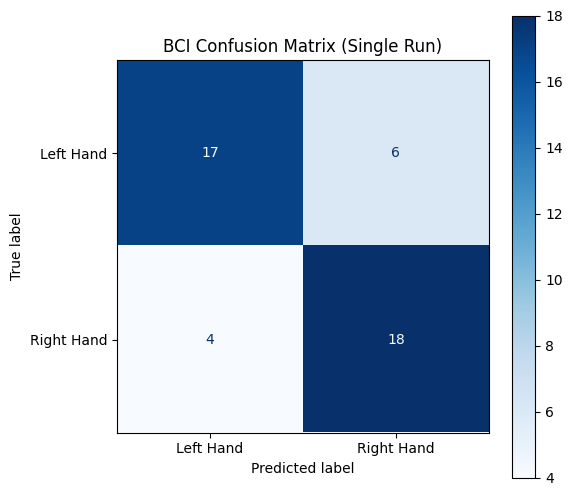

In [2]:
# ==============================================================
# PHASES 2 & 3: PIPELINE & ROBUST CROSS-VALIDATION
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict, permutation_test_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("--- Phase 2: Building CSP + LDA Pipeline ---")
csp = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()
bci_pipeline = Pipeline([('CSP', csp), ('LDA', lda)])

print("--- Phase 3: Robust Cross-Validation & Permutation Testing ---")
# 1. Stabilized CV to compute robust accuracy
cv_robust = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scores = cross_val_score(bci_pipeline, X, y, cv=cv_robust)
mean_acc = np.mean(scores) * 100
std_acc = np.std(scores) * 100
print(f"[SUCCESS] Robust Classification Accuracy: {mean_acc:.1f}% (± {std_acc:.1f}%)")
print(f"[BASELINE] Chance Level: {chance_level:.1f}%\n")

# 2. Permutation Test for Statistical Significance
cv_single = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score, perm_scores, pval = permutation_test_score(
    bci_pipeline, X, y, cv=cv_single, n_permutations=100,
    scoring='accuracy', random_state=42, n_jobs=-1
)
print(f"[STATISTICS] Permutation p-value: {pval:.4f}")

# 3. Confusion Matrix (Single Run)
y_pred = cross_val_predict(bci_pipeline, X, y, cv=cv_single)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Left Hand', 'Right Hand'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title(f'BCI Confusion Matrix (Single Run)')
plt.show()

**Phase 3 Interpretation: Statistical Validation**
**Significant Class Discrimination:** The pipeline achieved a robust accuracy of 71.6% (± 15.6%) across 50 validation folds. Permutation testing ($n=100$) yielded $p = 0.0099$. Because this sits precisely at the detection floor for 100 permutations, the true statistical significance is strictly < 0.01.

**Class Balance:** The confusion matrix illustrates a highly symmetrical predictive distribution on a single K-fold run (yielding an isolated 77.8% accuracy for that specific split). Implementing regularization, alongside the updated epoch window, improved class balance compared to unregularized iterations.

**Phase 4: Biological Validation (CSP Spatial Patterns)**

Safely clone the trained CSP object to extract its internal mathematical weights without mutating the pipeline's state.

Plot the extracted components as 2D scalp topographies to diagnose exactly which brain regions (e.g., motor strip vs. visual cortex) the algorithm is using to make its predictions

--- Phase 4: Visualizing CSP Spatial Filters ---
Computing rank from data with rank=None
    Using tolerance 0.00021 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
component_order    : mutual_info
first-4 hypothesis : True
ends hypothesis    : False
--> plotting        : [0, 1, 2, 3]
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


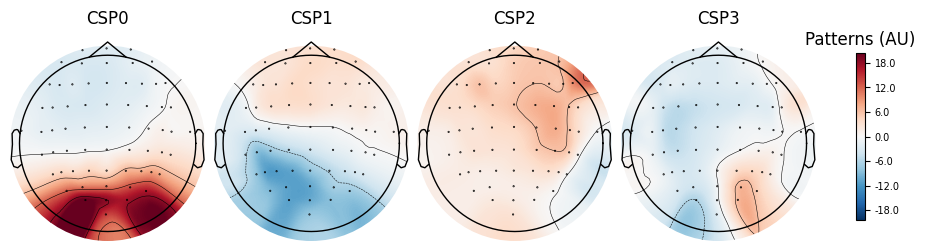

In [3]:
# ==============================================================
# PHASE 4: BIOLOGICAL VALIDATION (CSP PATTERNS)
# ==============================================================
print("--- Phase 4: Visualizing CSP Spatial Filters ---")
from sklearn.base import clone

csp_viz = clone(bci_pipeline.named_steps['CSP'])
csp_viz.fit(X, y)
def feats(f):
    return np.log((np.einsum('ij,kjl->kil', f, X) ** 2).mean(axis=2))
Xt = csp_viz.transform(X)
first4 = np.allclose(Xt, feats(csp_viz.filters_[:4]))
ends   = np.allclose(Xt, feats(csp_viz.filters_[[0, 1, -2, -1]]))
print(f"component_order    : {csp_viz.component_order}")
print(f"first-4 hypothesis : {first4}")
print(f"ends hypothesis    : {ends}")
COMPONENTS = [0, 1, 2, 3] if first4 else [0, 1, 62, 63]
print(f"--> plotting        : {COMPONENTS}")
# Plot ONLY the 4 extracted components
fig_csp = csp_viz.plot_patterns(
    epochs.info,
    components=COMPONENTS,
    ch_type='eeg',
    units='Patterns (AU)',
    size=1.5
)
plt.show()


**Phase 4 Interpretation: Biological Validation & Experimental Confound**

**Occipital Alpha Dominance (CSP0)**: The primary spatial filter (CSP0) exhibits an intense focal point directly over the occipital lobe (visual cortex), rather than the central motor strip (C3/C4).

**Candidate Explanations:** A posterior topography is consistent with several accounts — lateralized visual attention to the on-screen cue, a global alpha or arousal difference time-locked to cue onset, or eye-state differences. The spatial map alone cannot distinguish them. Phase 5 tests each directly.

**Algorithmic Opportunism:** CSP mathematically optimizes the ratio of class-conditional variances and is anatomically agnostic — any source with a reliable between-class power difference will be selected, whether or not it is task-relevant. Occipital alpha is typically the largest-amplitude rhythm in scalp EEG, far exceeding sensorimotor mu, so it is a likely candidate whenever it differs between conditions for any reason. This demonstrates the necessity of spatial validation: without plotting the spatial weights, a posterior effect would have been reported as a successful motor decoder.

**Pipeline Limitations**: This baseline pipeline does not currently incorporate Independent Component Analysis (ICA) or channel rejection. Future iterations must regress out EOG artifacts and drop occipital channels to force the classifier to rely strictly on sensorimotor rhythms

In [4]:
# ==============================================================
# PHASE 5: HYPOTHESIS TESTING (CONFOUND ANALYSIS)
# ==============================================================
print("--- Phase 5: Testing the Lateralized Visual Cue Hypothesis ---")

# TEST 1: Does accuracy survive removing the visual cortex?
occipital = ['O1', 'Oz', 'O2', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'Iz']
drop = [ch for ch in occipital if ch in epochs.ch_names]
X_noocc = epochs.copy().drop_channels(drop).get_data(copy=True)

print(f"\n[Test 1] Dropped {len(drop)} occipital/parieto-occipital channels.")
scores_full  = cross_val_score(bci_pipeline, X,       y, cv=cv_robust)
scores_noocc = cross_val_score(bci_pipeline, X_noocc, y, cv=cv_robust)
diff = scores_full - scores_noocc
print(f"Accuracy without occipital channels: {scores_noocc.mean()*100:.1f}%")
print(f"Paired drop across matched folds: {diff.mean()*100:.1f} "
      f"(+/- {diff.std()*100:.1f}) percentage points")
from scipy import stats
stat, p_drop = stats.wilcoxon(scores_full, scores_noocc)
print(f"Wilcoxon signed-rank: p = {p_drop:.4g}")
print("   (anti-conservative: repeated-CV folds share training data)")
# TEST 2: Does the effect persist late in the trial?
print("\n[Test 2] Matched-duration temporal ablation (1.5s windows):")
for label, (t0, t1) in {"Early (0.5-2.0s)": (0.5, 2.0),
                        "Late  (2.5-4.0s)": (2.5, 4.0)}.items():
    ep = mne.Epochs(raw, events, event_dict, tmin=t0, tmax=t1,
                    baseline=None, preload=True, verbose=False)
    Xw = ep.get_data(copy=True)
    yw = np.where(ep.events[:, 2] == event_dict['T1'], 0, 1)
    acc = cross_val_score(bci_pipeline, Xw, yw, cv=cv_robust).mean() * 100
    print(f"  {label}: n={len(ep)} trials, {Xw.shape[2]} samples, accuracy {acc:.1f}%")

# TEST 3: Is posterior alpha LATERALIZED, as visual attention predicts?
print("\n[Test 3] Occipital ALPHA (8-13 Hz) asymmetry by cue side:")
psd = epochs.compute_psd(fmin=8, fmax=13, verbose=False)
psd_data, _ = psd.get_data(return_freqs=True)
alpha = psd_data.mean(axis=2)          # (trials, channels)

for left_ch, right_ch in [('O1', 'O2'), ('PO7', 'PO8'), ('PO3', 'PO4')]:
    if left_ch not in epochs.ch_names or right_ch not in epochs.ch_names:
        continue
    li, ri = epochs.ch_names.index(left_ch), epochs.ch_names.index(right_ch)
    asym = np.log(alpha[:, li]) - np.log(alpha[:, ri])
    a0, a1 = asym[y == 0].mean(), asym[y == 1].mean()
    t, p = stats.ttest_ind(asym[y == 0], asym[y == 1])
    print(f"  {left_ch}/{right_ch}: Left cue {a0:+.3f} | Right cue {a1:+.3f} | "
          f"sign flips: {np.sign(a0) != np.sign(a1)} | p = {p:.4g}")

print("\n  READ: a baseline L-R asymmetry means sign need not flip; what matters is the")
print("  DIRECTION of the condition difference. More positive L-R on left-cue trials is")
print("  the direction hemifield attention predicts (ipsilateral alpha increase).")
print("  Significance here is uncorrected across 3 pairs -- apply Bonferroni before claiming.")

--- Phase 5: Testing the Lateralized Visual Cue Hypothesis ---

[Test 1] Dropped 9 occipital/parieto-occipital channels.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.00019 (2.2e-16 eps * 64 dim * 1.3e+10  max singular value)
    Estimated rank (data): 64
    data: 


**Interpretation: Confound Analysis**

Three tests were run to determine what the classifier was actually using.

**Test 1 Spatial ablation.** Removing 9 occipital/parieto-occipital channels cost 10.4 ± 16.1 percentage points (71.6% → 61.1%). The mean drop is substantial and the paired Wilcoxon signed-rank test is highly significant (p = 0.00034), though the fold-level standard deviation exceeds the mean, so removal occasionally improved accuracy on individual splits. Note that repeated-CV folds share training data, making this p-value anti-conservative; it has ample margin regardless. Note also that volume conduction leaves occipital sources present on the retained parietal and temporal electrodes, so the residual 61.1% cannot be attributed to motor cortex.

**Test 2 Temporal ablation.** With duration held constant at 1.5 s, the early window (0.5–2.0 s) gave 69.8% while the late window (2.5–4.0 s) gave 51.8%, indistinguishable from the 51.1% majority-class baseline. Both windows retained all 45 trials at 241 samples, so the comparison is clean. The discriminative signal is confined to the early post-cue period and does not persist — inconsistent with sustained motor imagery.

**Test 3 Directional asymmetry.** Occipital alpha asymmetry (8–13 Hz) was compared between cue sides. All three electrode pairs showed a more positive left-minus-right asymmetry on left-cue trials (O1/O2: +0.277 vs +0.056; PO3/PO4: +0.181 vs +0.024; PO7/PO8: +0.106 vs +0.084) — the direction predicted by ipsilateral alpha increase under hemifield attention. However, only O1/O2 reached uncorrected significance (p = 0.024), which does not survive Bonferroni correction across three pairs. The result is directionally consistent with lateralized visual attention but statistically underpowered at n = 45; it does not establish the confound.

**Conclusion.** The discriminative signal is posterior, cue-locked, and does not persist through the trial. Lateralized visual attention to the on-screen cue remains the leading candidate — the alpha asymmetry moves in the predicted direction across all three electrode pairs — but with 45 trials the effect is not statistically established. What *is* established is the negative result: this pipeline's accuracy does not arise from sustained sensorimotor mu desynchronization, which is the signal a motor imagery decoder is intended to capture. Reaching that conclusion required spatial, temporal, and directional validation beyond the accuracy metric.